In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import os
import numpy as np

In [4]:
results = [] # File Loading

path = './Results/Entire_Transformation_Matrix_W'

try:
    for filename in os.listdir(path):
        if filename in [".DS_Store", "Ablation_Results.csv"]:
            continue
        file_path = os.path.join(path, filename)
        if os.path.isfile(file_path):
            results.append(file_path)
except FileNotFoundError:
    print(f"Error: The Folder '{path}' was not found.")
except Exception as e:
    print(f"An error occured: {e}")

In [5]:
len(results) # Should be 22. Sanity Check

28

In [6]:
data = [pd.read_csv(i) for i in results]
data = sorted(data, key=lambda df: df.loc[0, "Train_Data_Size"])

# Columns
'''
data = {
    'Train_Data_Size': [train_size]*len(indices),
    "Transformation": [type if type != "" else "None"] * len(indices),
    'W': [W[i] for i in indices], # data.loc[0, "W"] -> First layer transformation
    'b': [b[i] for i in indices],
    'Accuracy': [correct[i] for i in indices], 
    "Co_Sim_CLS": [sim_cls[i] for i in indices],
}
'''

'\ndata = {\n    \'Train_Data_Size\': [train_size]*len(indices),\n    "Transformation": [type if type != "" else "None"] * len(indices),\n    \'W\': [W[i] for i in indices], # data.loc[0, "W"] -> First layer transformation\n    \'b\': [b[i] for i in indices],\n    \'Accuracy\': [correct[i] for i in indices], \n    "Co_Sim_CLS": [sim_cls[i] for i in indices],\n}\n'

In [7]:
data[0].loc[2, "Co_Sim_CLS"]

0.192372774178482

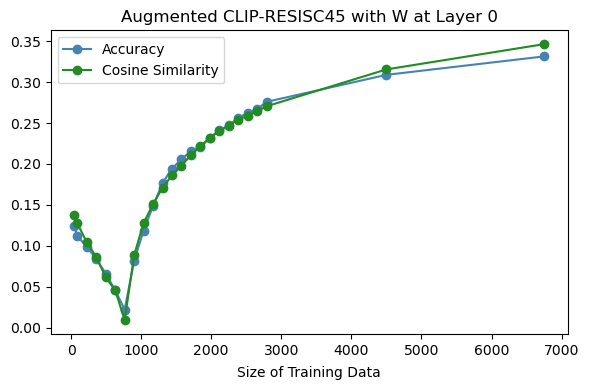

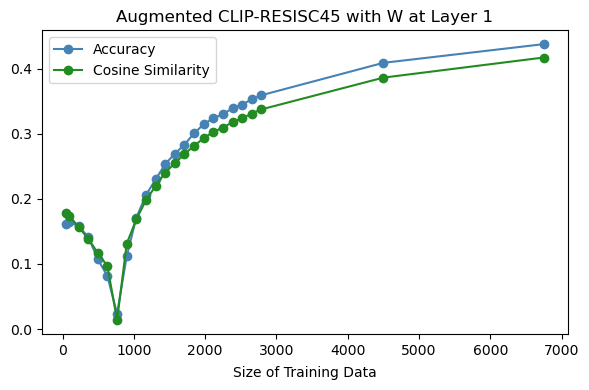

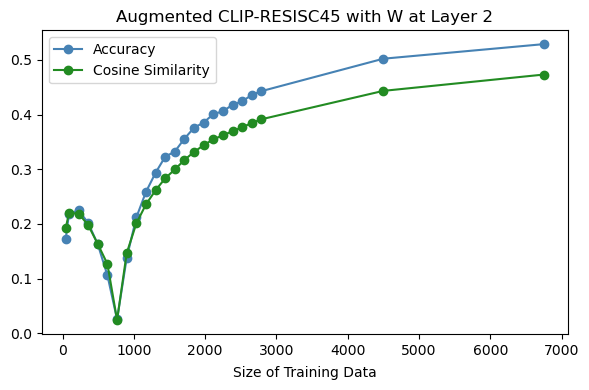

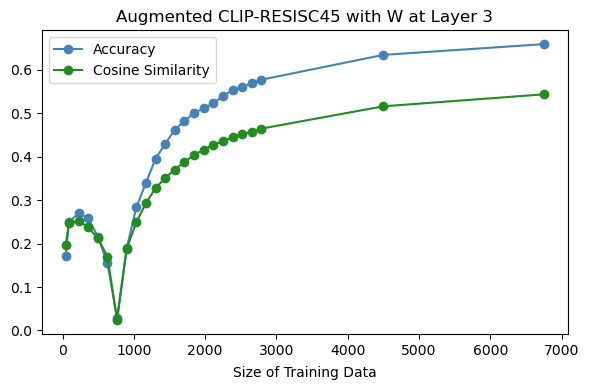

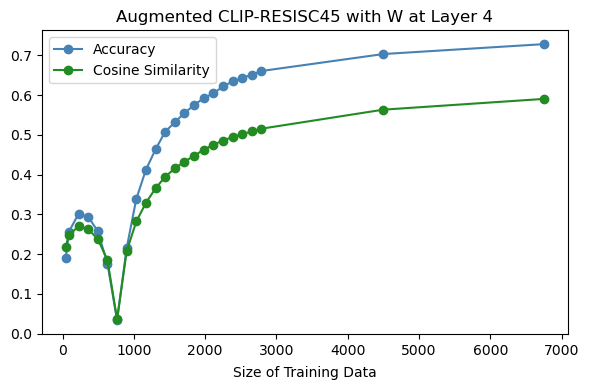

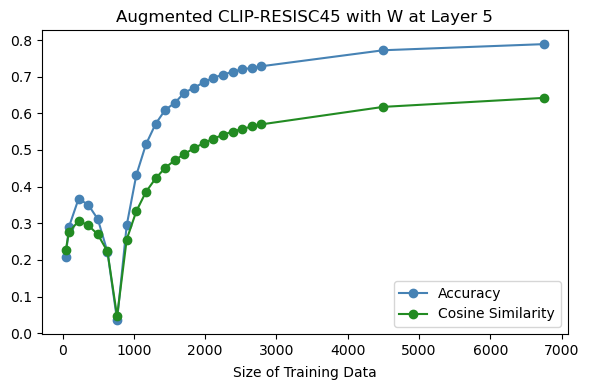

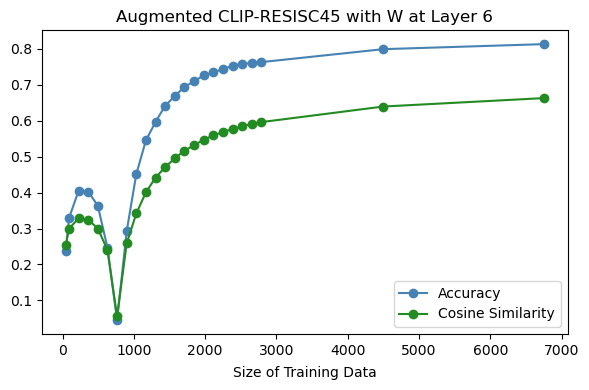

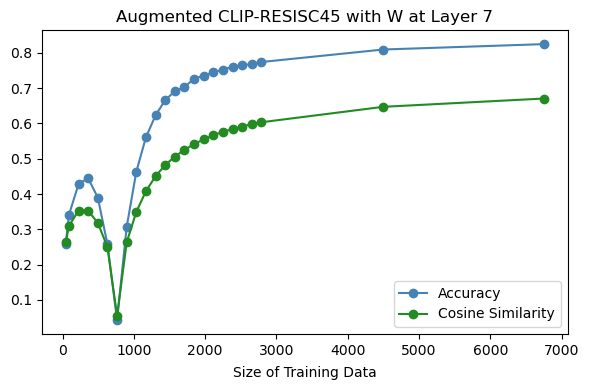

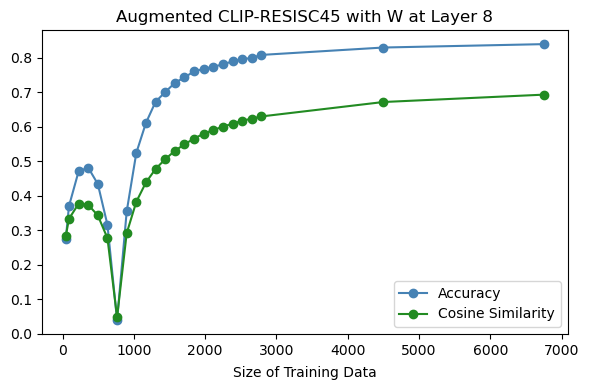

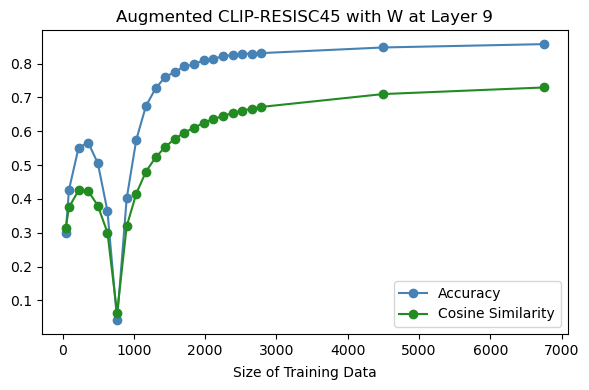

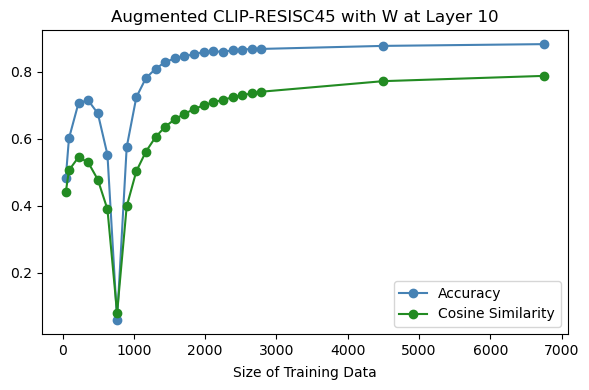

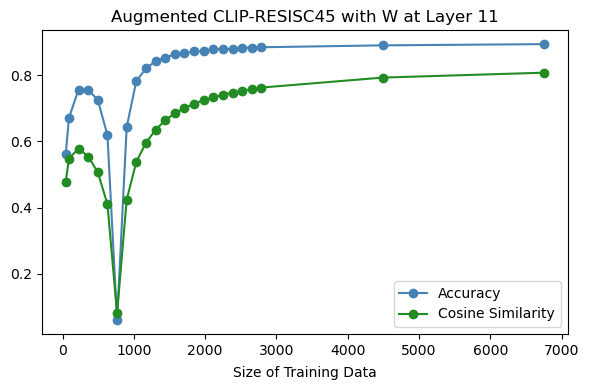

In [12]:
nrows = 2
ncols = 12

# figure, axes = plt.subplots(nrows, ncols)
for i in range(12): # For Each Layer
    plt.figure(figsize=(6,4))
    train_size = []
    acc = []
    co_sim_cls = []
    for j in range(24): # For Each File
        train_size.append(data[j].loc[i, "Train_Data_Size"])
        acc.append(data[j].loc[i, "Accuracy"])
        co_sim_cls.append(data[j].loc[i, "Co_Sim_CLS"])
    
    plt.plot(train_size, acc, marker='o', color='steelblue', label="Accuracy")
    plt.plot(train_size, co_sim_cls, marker='o', color="forestgreen", label="Cosine Similarity")
    plt.legend()
    plt.title(f"Augmented CLIP-RESISC45 with W at Layer {i}")
    plt.xlabel("Size of Training Data", labelpad=6)
    plt.tight_layout()
    plt.savefig(f'./Graphed_Results/Augmented_Layer_{i}', dpi=600)
    plt.show()

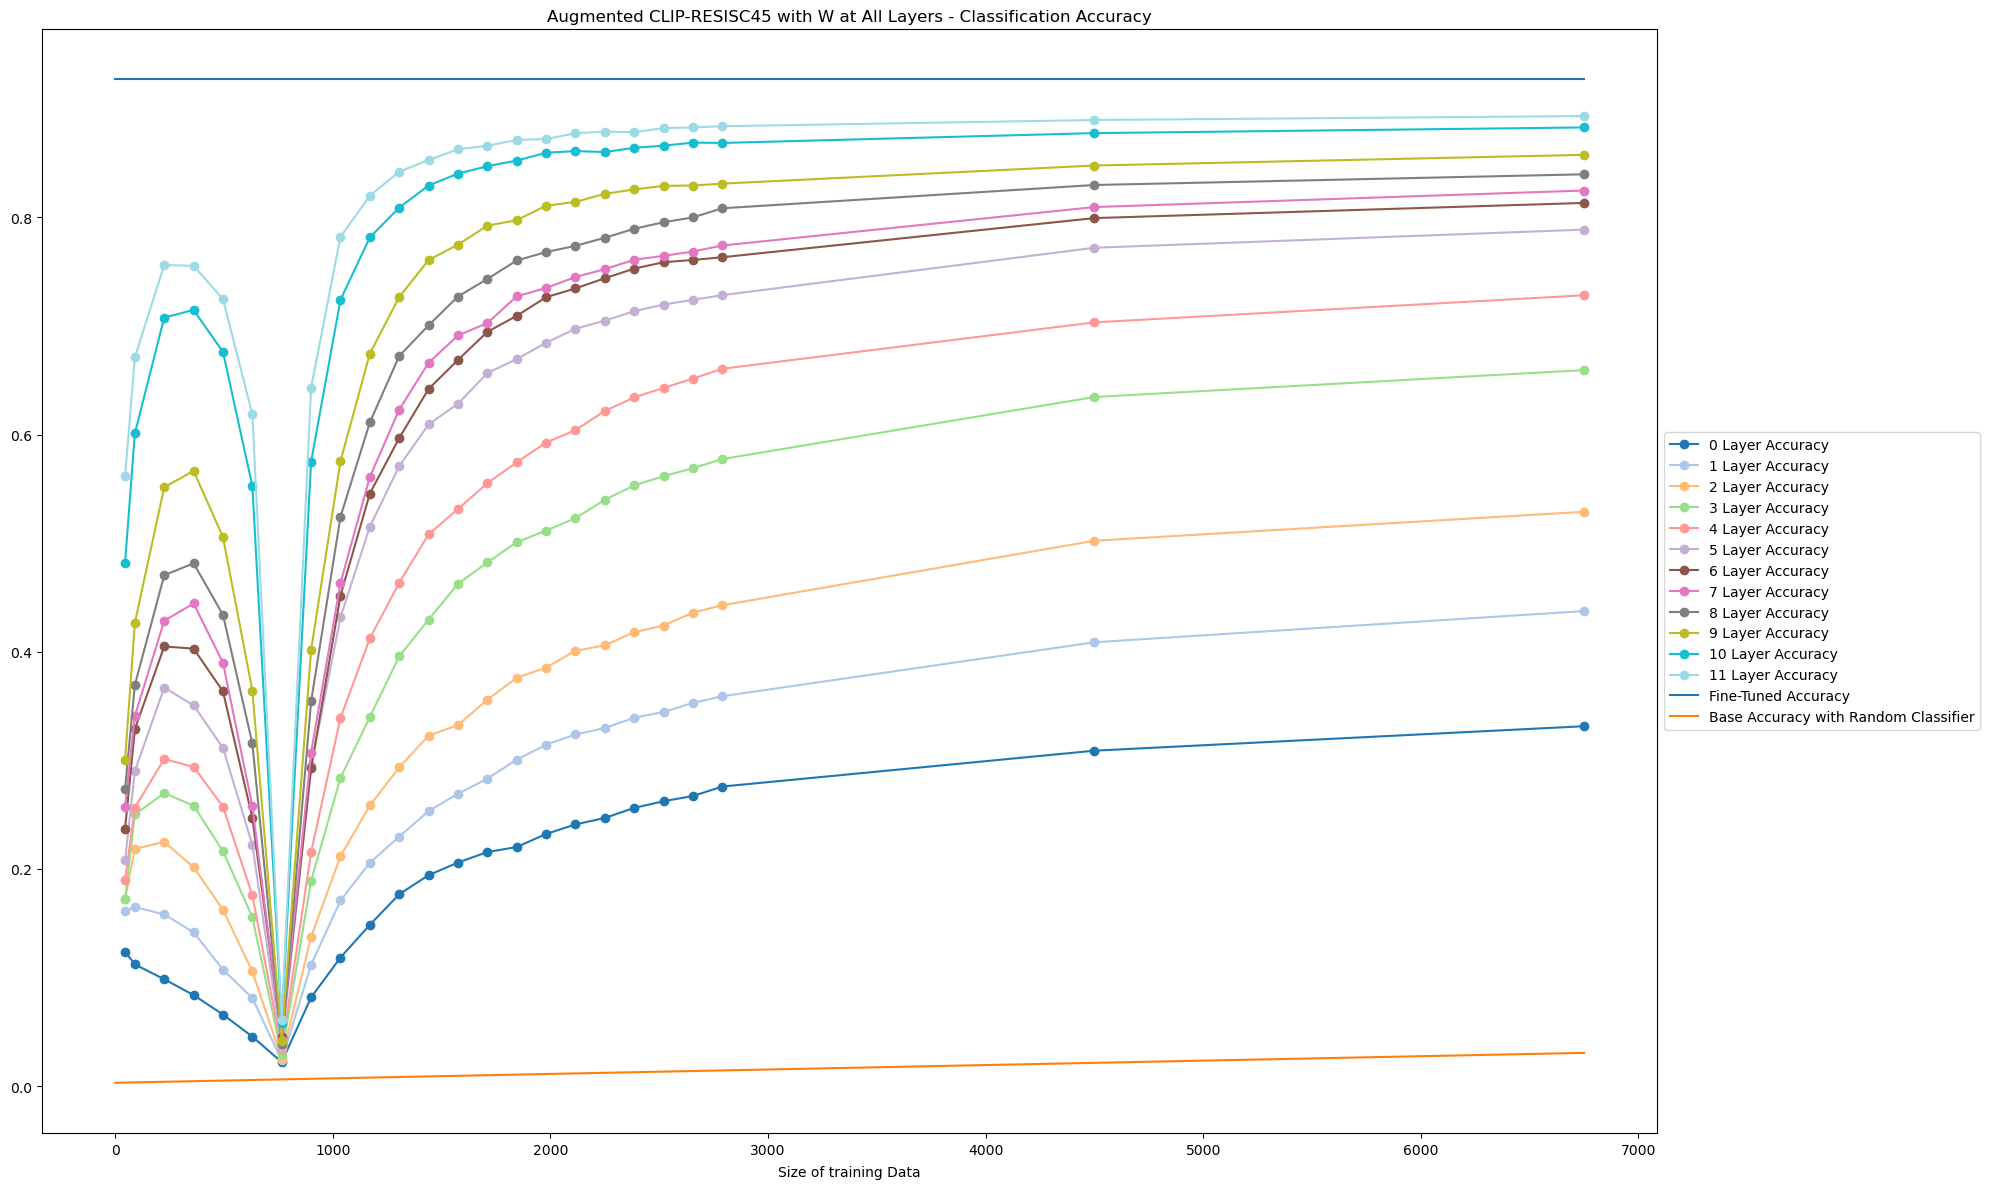

In [14]:
# All Accuracy Together
train_size = []
for i in range(24):
    train_size.append(data[i].loc[0, "Train_Data_Size"])
acc_vals = {}
for i in range(12):
    acc_vals[i] = []
for i in range(12):
    for j in range(24):
        acc_vals[i].append(data[j].loc[i, "Accuracy"])

colors = plt.cm.tab20(np.linspace(0,1,12))
plt.figure(figsize=(20,12))
for i in range(12):
    plt.plot(train_size, acc_vals[i], marker="o", color=colors[i], label=f"{i} Layer Accuracy")
plt.plot([0, 6750], [0.9270, 0.9270], label="Fine-Tuned Accuracy")
plt.plot([0, 6750], [0.00306, 0.0306], label="Base Accuracy with Random Classifier")

plt.legend(
    loc="center left",
    bbox_to_anchor=(1.0, 0.5)
)
plt.title("Augmented CLIP-RESISC45 with W at All Layers - Classification Accuracy")
plt.xlabel("Size of training Data", labelpad=6)
plt.tight_layout()
plt.savefig(f'./Graphed_Results/All_Augmented_Layers_Classifiction_Accuracy', dpi=600)
plt.show()

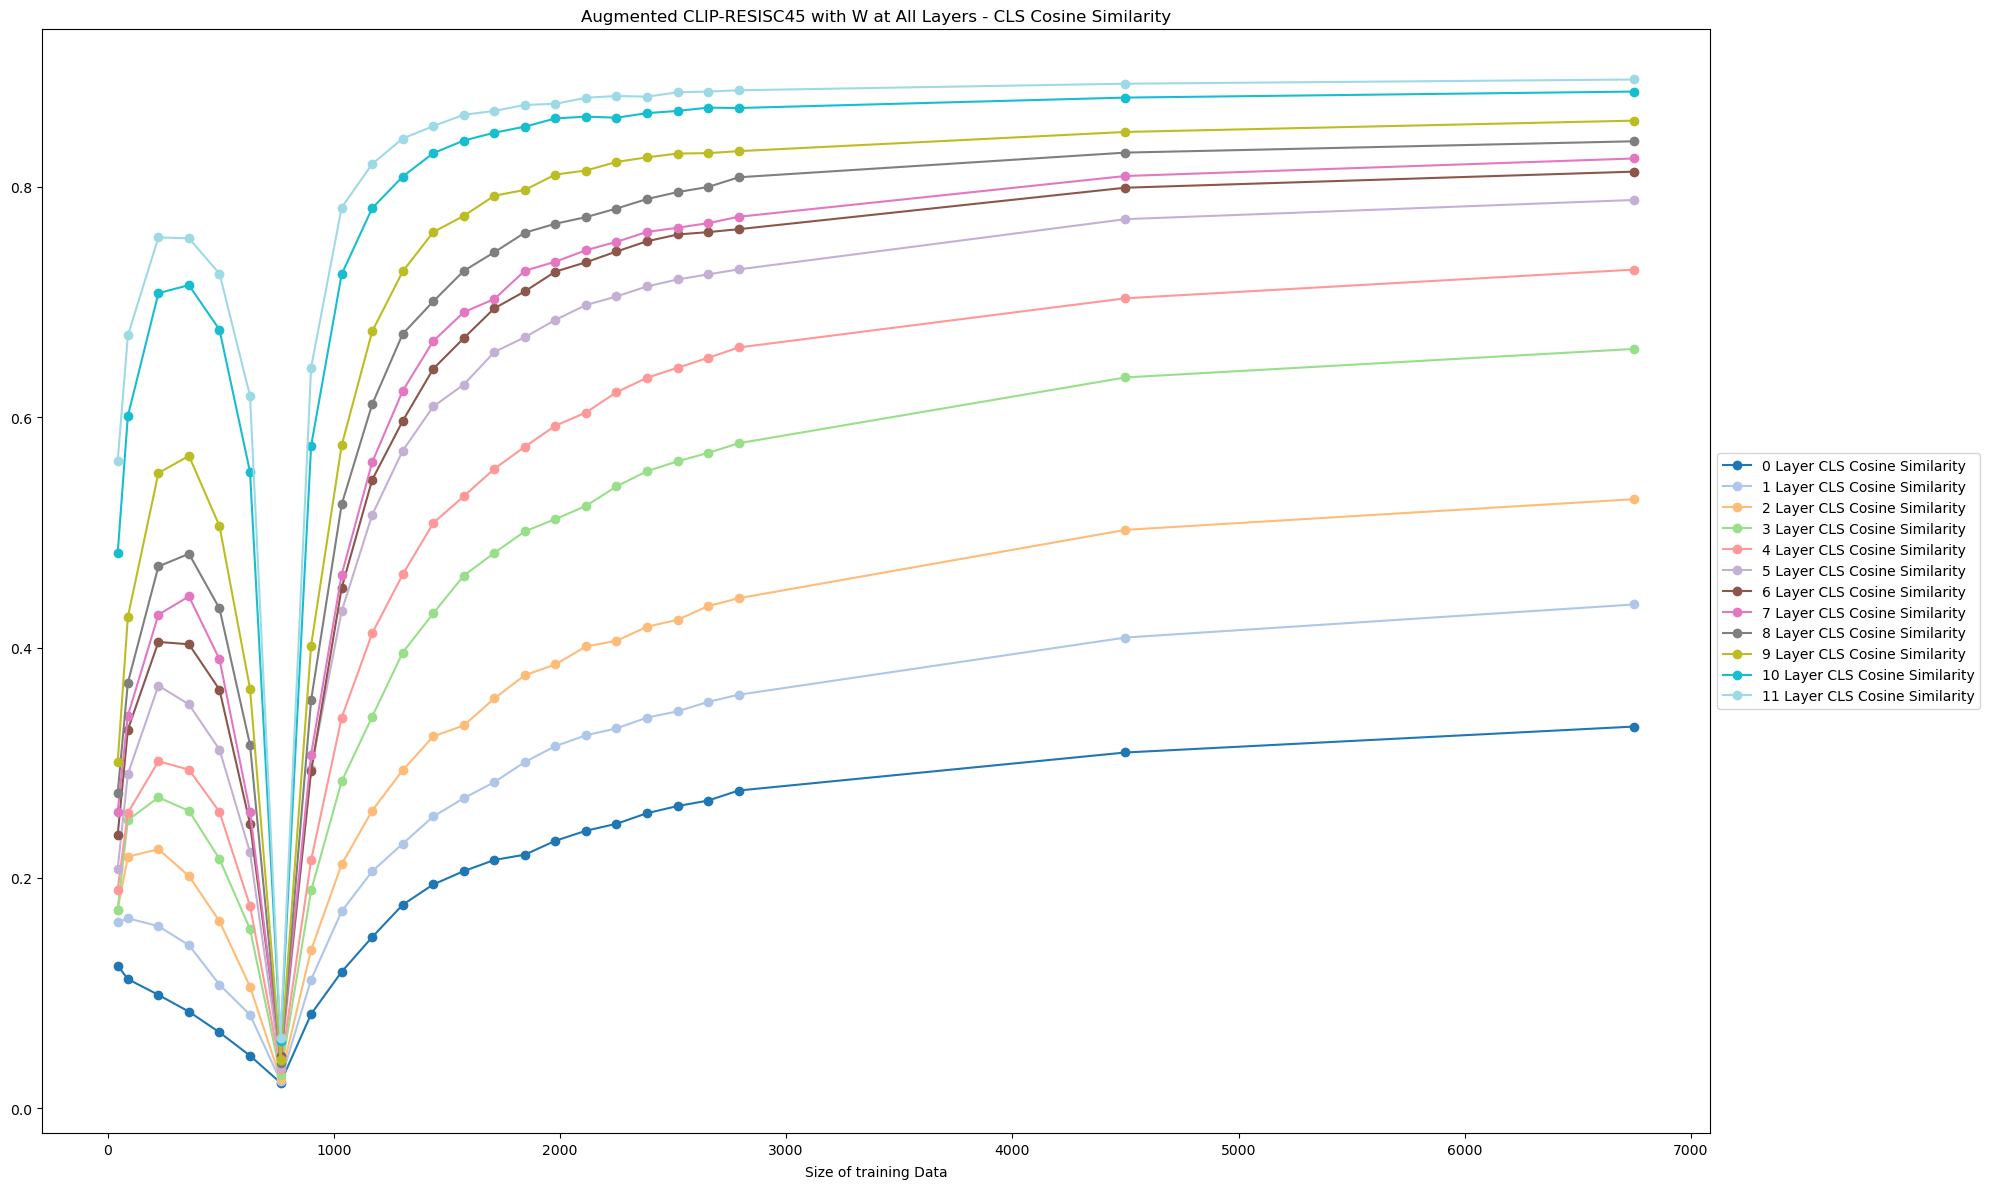

In [16]:
train_size = []
for i in range(24):
    train_size.append(data[i].loc[0, "Train_Data_Size"])
cls_vals = {}
for i in range(12):
    cls_vals[i] = []
for i in range(12):
    for j in range(24):
        cls_vals[i].append(data[j].loc[i, "Co_Sim_CLS"])

colors = plt.cm.tab20(np.linspace(0,1,12))
plt.figure(figsize=(20,12))
for i in range(12):
    plt.plot(train_size, acc_vals[i], marker="o", color=colors[i], label=f"{i} Layer CLS Cosine Similarity")
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.0, 0.5)
)
plt.title("Augmented CLIP-RESISC45 with W at All Layers - CLS Cosine Similarity")
plt.xlabel("Size of training Data", labelpad=6)
plt.tight_layout()
plt.savefig(f'./Graphed_Results/All_Augmented_Layers_CLS_Cosine_Similarity', dpi=600)
plt.show()

## Ablation Graphs

In [19]:
results = [] # File Loading

results.append('./Results/Entire_Transformation_Matrix_W/Transformation_Matrix_W_Entire_Size_15120_Augmentation_Results.csv')
results.append('./Results/Entire_Transformation_Matrix_W/Ablation_Results.csv')

In [20]:
results = [pd.read_csv(i) for i in results]

In [21]:
acc = []
co_sim_cls = []

acc_aug = []
co_sim_cls_aug = []

for i in range(11):
    acc_aug.append(results[0].loc[i, "Accuracy"])
    co_sim_cls_aug.append(results[0].loc[i, "Co_Sim_CLS"])
    acc.append(results[1].loc[i, "Accuracy"])
    co_sim_cls.append(results[1].loc[i, "Co_Sim_CLS"])

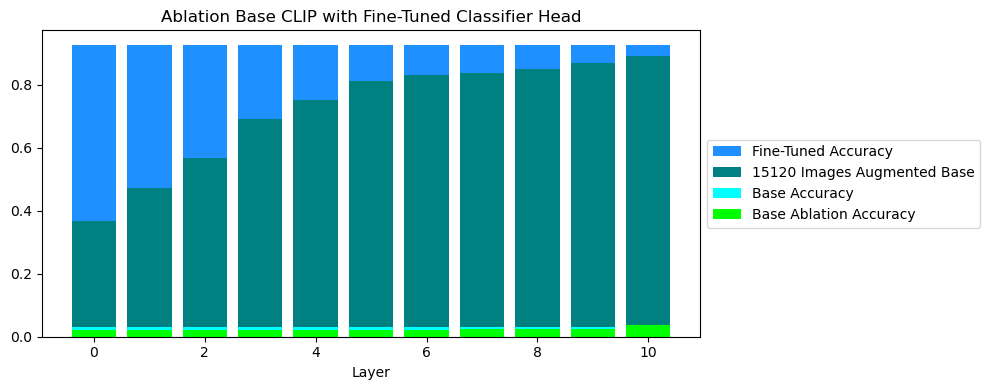

In [24]:
plt.figure(figsize=(10,4))


# plt.bar([i for i in range(11)], co_sim_cls, color="forestgreen", label="Cosine Similarity")
plt.bar([i for i in range(11)], 0.9270, color="dodgerblue", label="Fine-Tuned Accuracy")
plt.bar([i for i in range(11)], acc_aug, color="teal", label="15120 Images Augmented Base")
plt.bar([i for i in range(11)], 0.0306, color="cyan", label="Base Accuracy")
plt.bar([i for i in range(11)], acc, color="lime", label="Base Ablation Accuracy")
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.0, 0.5)
)
plt.title(f"Ablation Base CLIP with Fine-Tuned Classifier Head")
plt.xlabel("Layer")
plt.tight_layout()
plt.savefig(f'./Graphed_Results/Ablation_Classification_Accuracy', dpi=600)
plt.show()